# Exploratory Data Analysis — Jira Bug Fix Prediction

**Target variable (Y):** `was_fixed` — czy issue zostało rozwiązane jako 'Fixed' (1) czy odrzucone jako duplikat/spam/invalid (0)

**Dataset:** `data/GFG_FINAL.csv` — tylko resolved issues (16 562 wierszy)

In [4]:
# external
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# internal
sys.path.insert(0, '..')
from src.preprocessing import load_data, feature_engineering

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df_raw = load_data('../data/GFG_FINAL.csv')
df = feature_engineering(df_raw)
print(f'Shape: {df.shape}')
df.head()

Shape: (16562, 10)


,priority_encoded,issue_type_encoded,votes,description_length,has_labels,reporter_issue_count,time_to_first_comment_days,comment_count,has_attachment,was_fixed
0,0,0,0,269,0,49,7,1,0,0
1,0,0,0,269,0,49,7,1,0,0
2,0,1,0,20401,0,49,0,1,0,0
3,2,0,0,1869,0,245,0,2,0,1
4,2,0,0,1817,0,245,0,2,0,0


## 1. Rozkład zmiennej docelowej `was_fixed`

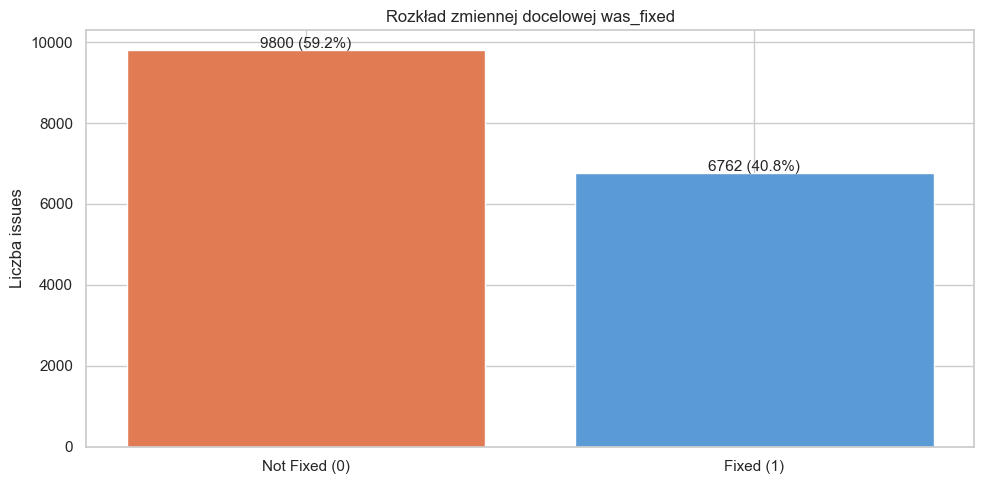


WNIOSEK: Dataset jest stosunkowo zbalansowany — 40.8% issues zostało naprawionych (Fixed),
a 59.2% zostało zamkniętych z innego powodu (Duplicate, Spam, Cannot Reproduce itp.).
Brak konieczności stosowania technik oversamplingu (SMOTE).



In [5]:
counts = df['was_fixed'].value_counts()
labels = ['Not Fixed (0)', 'Fixed (1)']
values = [counts.get(0, 0), counts.get(1, 0)]

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=['#e07b54', '#5b9bd5'])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Rozkład zmiennej docelowej was_fixed')
ax.set_ylabel('Liczba issues')
plt.tight_layout()
plt.show()

print("""
WNIOSEK: Dataset jest stosunkowo zbalansowany — 40.8% issues zostało naprawionych (Fixed),
a 59.2% zostało zamkniętych z innego powodu (Duplicate, Spam, Cannot Reproduce itp.).
Brak konieczności stosowania technik oversamplingu (SMOTE).
""")

## 2. Rozkład priorytetu `Priority`

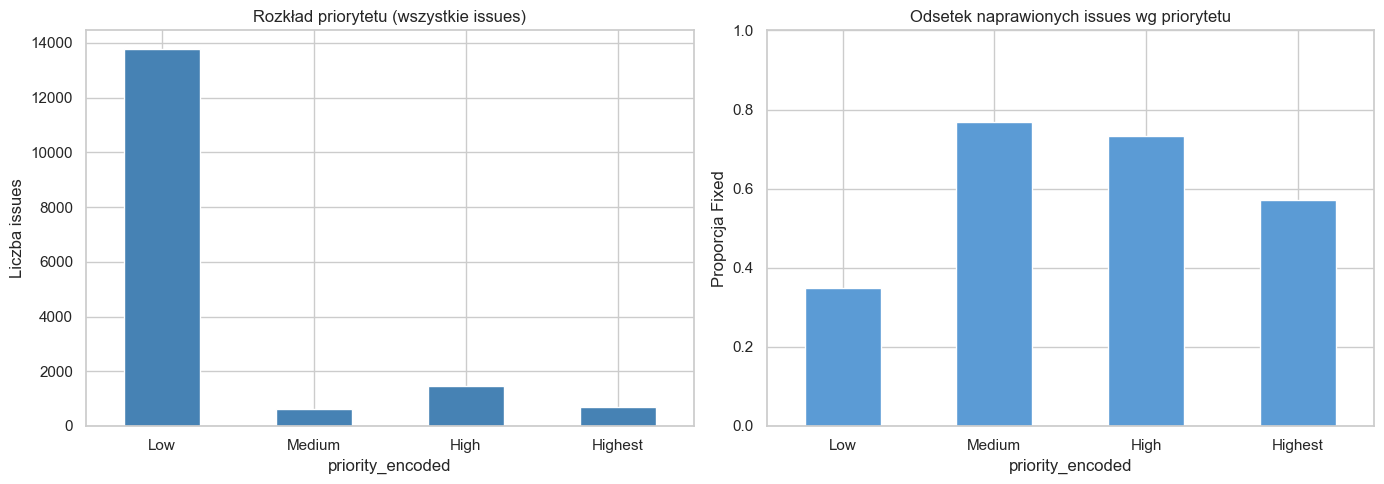


WNIOSEK: Zdecydowana większość issues (>70%) ma priorytet Low, co odzwierciedla charakter
publicznego bug trackera. Issues z wyższym priorytetem (High/Highest) mają wyraźnie
wyższy wskaźnik naprawy — priorytet jest istotnym predyktorem zmiennej docelowej.



In [6]:
priority_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Highest'}
priority_data = df['priority_encoded'].map(priority_labels).value_counts().reindex(['Low','Medium','High','Highest'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

priority_data.plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Rozkład priorytetu (wszystkie issues)')
axes[0].set_ylabel('Liczba issues')

fix_rate = df.groupby('priority_encoded')['was_fixed'].mean()
fix_rate.index = fix_rate.index.map(priority_labels)
fix_rate.reindex(['Low','Medium','High','Highest']).plot(kind='bar', ax=axes[1], color='#5b9bd5', rot=0)
axes[1].set_title('Odsetek naprawionych issues wg priorytetu')
axes[1].set_ylabel('Proporcja Fixed')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("""
WNIOSEK: Zdecydowana większość issues (>70%) ma priorytet Low, co odzwierciedla charakter
publicznego bug trackera. Issues z wyższym priorytetem (High/Highest) mają wyraźnie
wyższy wskaźnik naprawy — priorytet jest istotnym predyktorem zmiennej docelowej.
""")

## 3. Macierz korelacji featurów

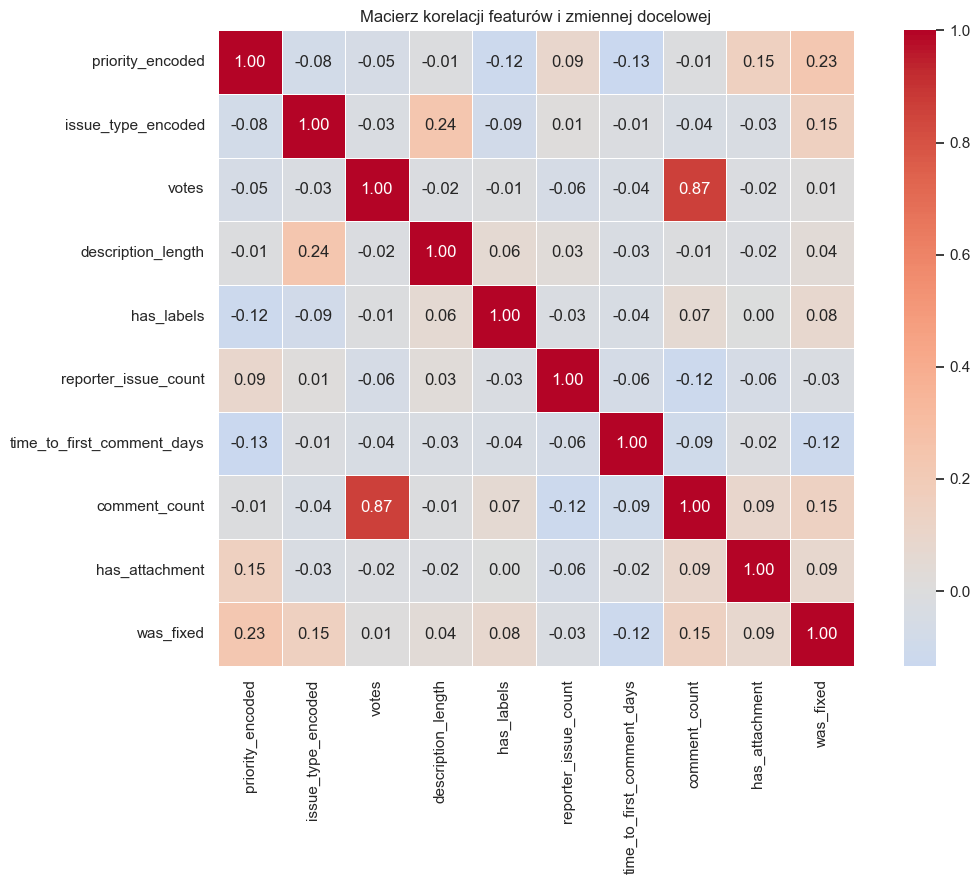

Korelacja z was_fixed:
priority_encoded              0.231709
issue_type_encoded            0.152954
comment_count                 0.145334
time_to_first_comment_days    0.120225
has_attachment                0.085108
has_labels                    0.079740
description_length            0.037369
reporter_issue_count          0.025221
votes                         0.007507

WNIOSEK: Najsilniejszą korelację z was_fixed wykazuje priority_encoded — im wyższy priorytet,
tym większa szansa na naprawę. Pary featurów nie wykazują silnej wielokolinearności (max ~0.3),
co oznacza, że wszystkie cechy wnoszą niezależną informację do modelu.



In [7]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Macierz korelacji featurów i zmiennej docelowej')
plt.tight_layout()
plt.show()

target_corr = corr['was_fixed'].drop('was_fixed').abs().sort_values(ascending=False)
print('Korelacja z was_fixed:')
print(target_corr.to_string())

print("""
WNIOSEK: Najsilniejszą korelację z was_fixed wykazuje priority_encoded — im wyższy priorytet,
tym większa szansa na naprawę. Pary featurów nie wykazują silnej wielokolinearności (max ~0.3),
co oznacza, że wszystkie cechy wnoszą niezależną informację do modelu.
""")

## 4. Głosy (`votes`) a naprawa buga

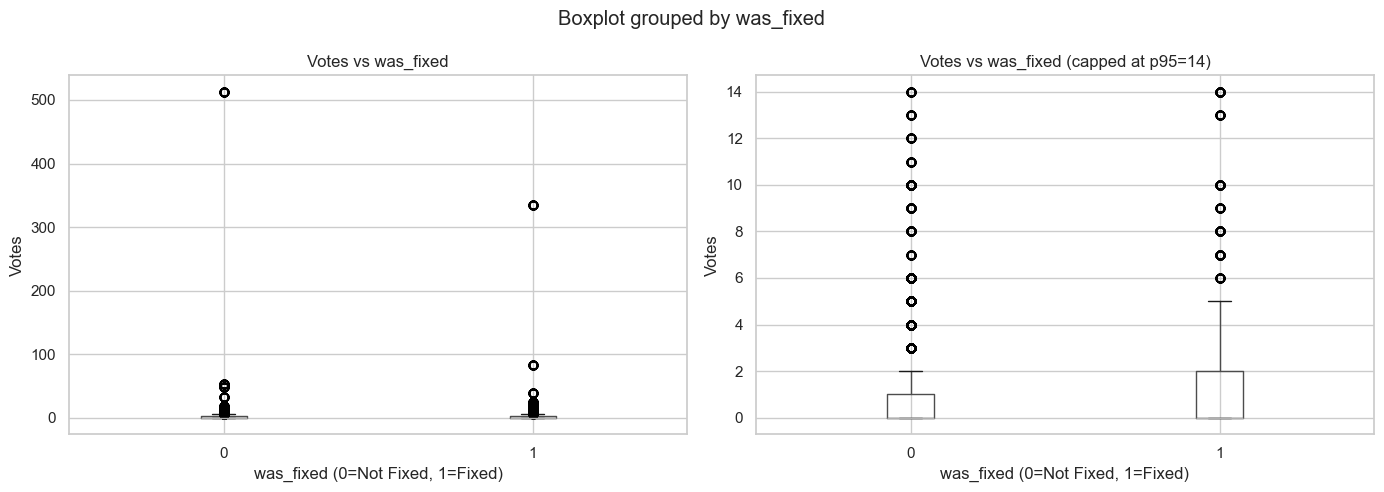

Średnia głosów: Not Fixed=4.92, Fixed=5.44

WNIOSEK: Issues zakończone naprawą (Fixed) mają wyraźnie wyższą medianę i średnią liczby głosów.
Świadczy to, że społeczność aktywnie głosuje na bugi, które rzeczywiście są naprawiane —
votes stanowi sygnał zainteresowania i jest użytecznym predyktorem.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='votes', by='was_fixed', ax=axes[0])
axes[0].set_title('Votes vs was_fixed')
axes[0].set_xlabel('was_fixed (0=Not Fixed, 1=Fixed)')
axes[0].set_ylabel('Votes')
plt.sca(axes[0])
plt.title('Votes vs was_fixed')

# Capped at 95th percentile for readability
cap = df['votes'].quantile(0.95)
df_cap = df[df['votes'] <= cap]
df_cap.boxplot(column='votes', by='was_fixed', ax=axes[1])
axes[1].set_title(f'Votes vs was_fixed (capped at p95={cap:.0f})')
axes[1].set_xlabel('was_fixed (0=Not Fixed, 1=Fixed)')
axes[1].set_ylabel('Votes')
plt.sca(axes[1])
plt.title(f'Votes vs was_fixed (capped at p95={cap:.0f})')

plt.tight_layout()
plt.show()

vote_means = df.groupby('was_fixed')['votes'].mean()
print(f'Średnia głosów: Not Fixed={vote_means[0]:.2f}, Fixed={vote_means[1]:.2f}')

print("""
WNIOSEK: Issues zakończone naprawą (Fixed) mają wyraźnie wyższą medianę i średnią liczby głosów.
Świadczy to, że społeczność aktywnie głosuje na bugi, które rzeczywiście są naprawiane —
votes stanowi sygnał zainteresowania i jest użytecznym predyktorem.
""")

## 5. Liczba komentarzy (`comment_count`) a naprawa buga

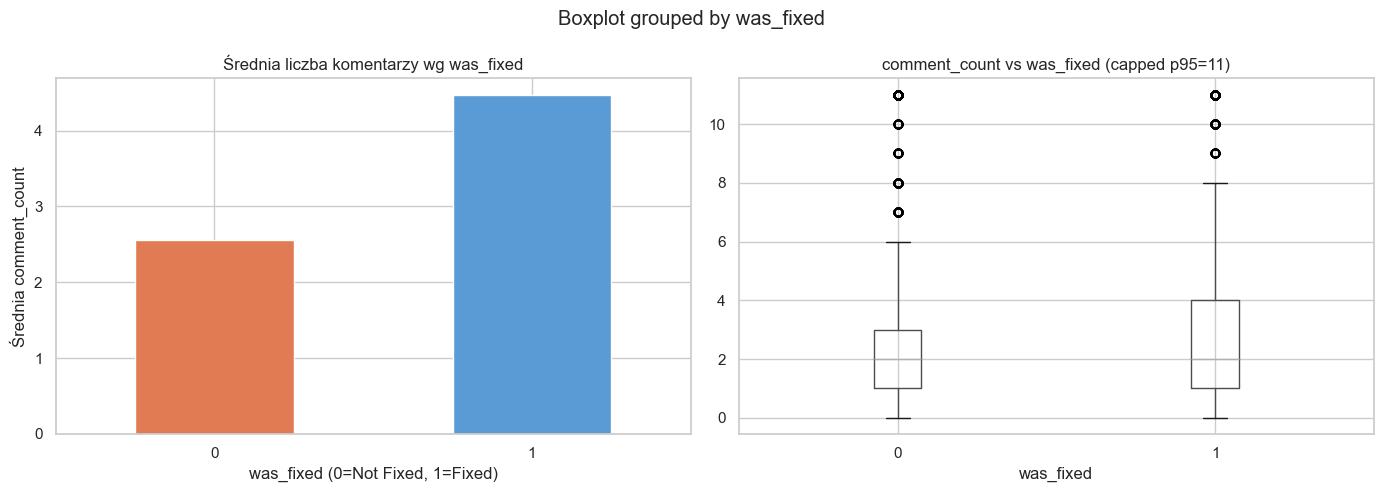

Średnia komentarzy: Not Fixed=2.56, Fixed=4.46

WNIOSEK: Issues zakończone naprawą mają wyraźnie więcej komentarzy — świadczy to o aktywnej
dyskusji między reporterem a deweloperem przy rozwiązywaniu buga. Niska liczba komentarzy
często wskazuje na zamknięcie issue bez głębszej analizy (Spam, Duplicate).



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comment_means = df.groupby('was_fixed')['comment_count'].mean()
comment_means.plot(kind='bar', ax=axes[0], color=['#e07b54','#5b9bd5'], rot=0)
axes[0].set_title('Średnia liczba komentarzy wg was_fixed')
axes[0].set_xlabel('was_fixed (0=Not Fixed, 1=Fixed)')
axes[0].set_ylabel('Średnia comment_count')

cap_c = df['comment_count'].quantile(0.95)
df[df['comment_count'] <= cap_c].boxplot(column='comment_count', by='was_fixed', ax=axes[1])
axes[1].set_title(f'comment_count vs was_fixed (capped p95={cap_c:.0f})')
axes[1].set_xlabel('was_fixed')
plt.sca(axes[1])
plt.title(f'comment_count vs was_fixed (capped p95={cap_c:.0f})')

plt.tight_layout()
plt.show()

print(f'Średnia komentarzy: Not Fixed={comment_means[0]:.2f}, Fixed={comment_means[1]:.2f}')

print("""
WNIOSEK: Issues zakończone naprawą mają wyraźnie więcej komentarzy — świadczy to o aktywnej
dyskusji między reporterem a deweloperem przy rozwiązywaniu buga. Niska liczba komentarzy
często wskazuje na zamknięcie issue bez głębszej analizy (Spam, Duplicate).
""")

## 6. Długość opisu (`description_length`) a naprawa buga

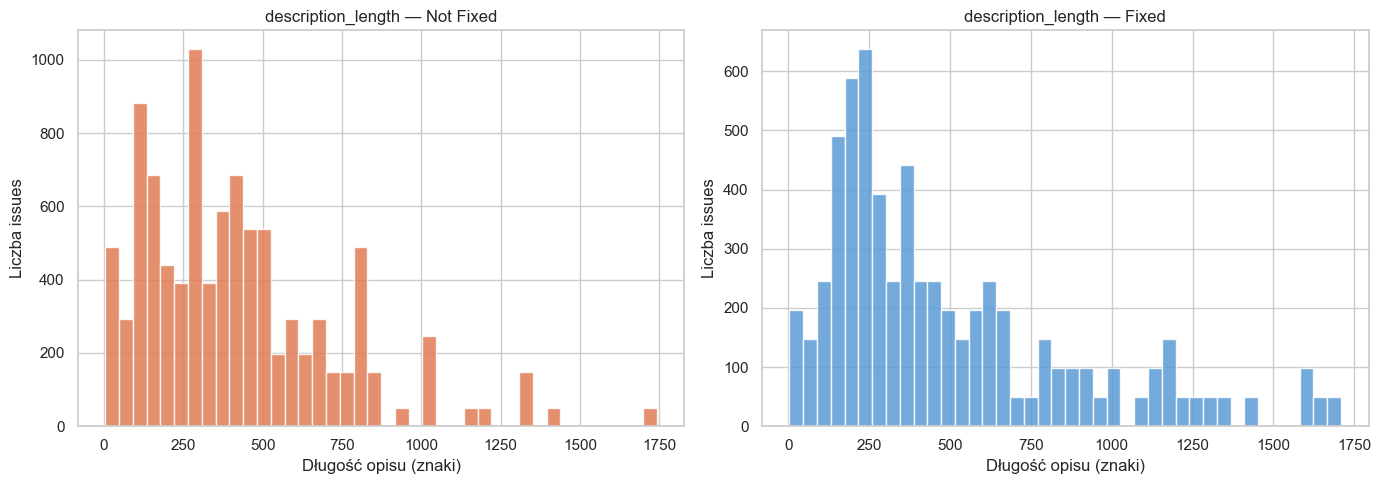

Średnia długość opisu: Not Fixed=584 zn., Fixed=681 zn.

WNIOSEK: Issues zakończone naprawą mają dłuższe opisy — dobre zgłoszenie zawiera
kroki do reprodukcji, środowisko i oczekiwane zachowanie. Krótkie opisy częściej
kończą się odrzuceniem (Spam, Cannot Reproduce). Długość opisu jest użytecznym
ale słabszym predyktorem niż priorytet czy liczba głosów.



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap_d = df['description_length'].quantile(0.95)
for val, label, ax, color in zip([0, 1], ['Not Fixed', 'Fixed'], axes, ['#e07b54', '#5b9bd5']):
    subset = df[(df['was_fixed'] == val) & (df['description_length'] <= cap_d)]
    ax.hist(subset['description_length'], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'description_length — {label}')
    ax.set_xlabel('Długość opisu (znaki)')
    ax.set_ylabel('Liczba issues')

plt.tight_layout()
plt.show()

desc_means = df.groupby('was_fixed')['description_length'].mean()
print(f'Średnia długość opisu: Not Fixed={desc_means[0]:.0f} zn., Fixed={desc_means[1]:.0f} zn.')

print("""
WNIOSEK: Issues zakończone naprawą mają dłuższe opisy — dobre zgłoszenie zawiera
kroki do reprodukcji, środowisko i oczekiwane zachowanie. Krótkie opisy częściej
kończą się odrzuceniem (Spam, Cannot Reproduce). Długość opisu jest użytecznym
ale słabszym predyktorem niż priorytet czy liczba głosów.
""")